In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from fusionaihub.datasets.prepare import prepare2 as p2

In [50]:
cfg = p2.sample_cfg
shot = 170000

In [141]:
import h5py

In [146]:
import h5py

def get_h5_attrs(directory, shot):
    with h5py.File(directory + f'/{shot}.h5', 'r') as f:
        mhr_group = f['p_inj']
        for attr_name, attr_value in mhr_group.attrs.items():
            print(f"  {attr_name}: {attr_value}")

# Get attrs for shot 170000
get_h5_attrs(cfg["raw_data_dir"], 170000)

  CLASS: b'GROUP'
  TITLE: Empty(dtype=dtype('S1'))
  VERSION: b'1.0'
  axis0_variety: b'regular'
  axis1_variety: b'regular'
  block0_items_variety: b'regular'
  encoding: b'UTF-8'
  end_time_ms: 13100.0
  errors: b'strict'
  missing_channels: Empty(dtype=dtype('S1'))
  nblocks: 1
  ndim: 2
  pandas_type: b'frame'
  pandas_version: b'0.15.2'
  r_coordinates: b'N.'
  sampling_frequency_kHz: 100.00000223517424
  start_time_ms: 0.0
  z_coordinates: b'N.'


In [167]:
import pandas as pd

with pd.HDFStore(cfg["raw_data_dir"] + '/170000.h5', "r") as store:
    print(store.keys())
    signal = store['gas']

signal

['/bes', '/bes_slow', '/beta', '/cer_amp', '/cer_amp_error', '/cer_coord_phi', '/cer_coord_r', '/cer_coord_z', '/cer_fz', '/cer_nz', '/cer_rot', '/cer_rot_error', '/cer_ti', '/cer_ti_error', '/cer_vb', '/cer_vb_error', '/cer_zeff', '/co2_density', '/co2_density_slow', '/co2_phase', '/coil_field_strength', '/d_alpha', '/divertor_geo', '/e_dens_fit', '/e_temp_fit', '/ece_cali', '/ece_slow', '/ech', '/gas', '/i_dens_fit', '/i_temp_fit', '/ip', '/mag_b0', '/mag_geo_para', '/mag_mode_number', '/mag_others', '/mag_pcb_coil', '/magnetics', '/magnetics_high_resolution', '/mse', '/neutron', '/other_profiles', '/p_inj', '/pressure', '/psi_r_z', '/q_psi', '/rho_qmin', '/rmp_current', '/ssi', '/t_inj', '/t_rot_fit', '/ts_core_density', '/ts_core_density_error', '/ts_core_temperature', '/ts_core_temperature_error', '/ts_divertor_density', '/ts_divertor_density_error', '/ts_divertor_temperature', '/ts_divertor_temperature_error', '/ts_tangential_density', '/ts_tangential_density_error', '/ts_tangent

,gasa,gasb,gasc,gasd,gase
Time [ms],,,,,
-8053.600098,0.007401,0.010383,0.004932,0.011607,0.008635
-8053.549805,-0.000617,0.004886,0.006781,0.010996,0.003701
-8053.500000,0.014802,0.007940,0.011096,0.008552,0.009252
-8053.450195,-0.006168,0.002443,0.002466,-0.000611,-0.001234
-8053.399902,0.008635,0.018323,0.004932,0.012217,0.006168
...,...,...,...,...,...
11606.950195,0.003701,0.007940,-0.001849,-0.001222,0.004318
11607.000000,-0.014185,-0.000611,-0.017877,-0.010996,-0.012953
11607.049805,0.006168,0.018323,0.000000,0.001222,-0.001234


In [168]:
channel = signal['gasa']

<Axes: xlabel='Time [ms]'>

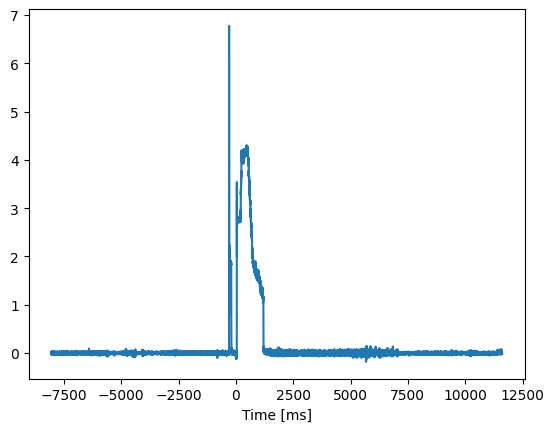

In [172]:
channel.plot()

In [152]:
import torch

In [159]:
# Apply STFT transform to the channel data
x_tensor = torch.from_numpy(channel.values).float()
stft_result = torch.stft(
    x_tensor, 
    n_fft=1024, 
    hop_length=256, 
    window=torch.hann_window(1024), 
    return_complex=True
)
# Take log of absolute values
log_abs_stft = torch.log(torch.abs(stft_result))

In [162]:
# Decimate the original signal to match the STFT time dimension
stft_time_frames = log_abs_stft.shape[1]
original_length = len(channel)

print(f"Original signal length: {original_length}")
print(f"STFT time frames: {stft_time_frames}")
print(f"Decimation factor: {original_length / stft_time_frames}")

# Create decimated signal by taking every nth sample
decimation_factor = original_length // stft_time_frames
decimated_signal = channel.values[::decimation_factor][:stft_time_frames]

print(f"Decimated signal length: {len(decimated_signal)}")


Original signal length: 1310001
STFT time frames: 5118
Decimation factor: 255.95955451348183
Decimated signal length: 5118


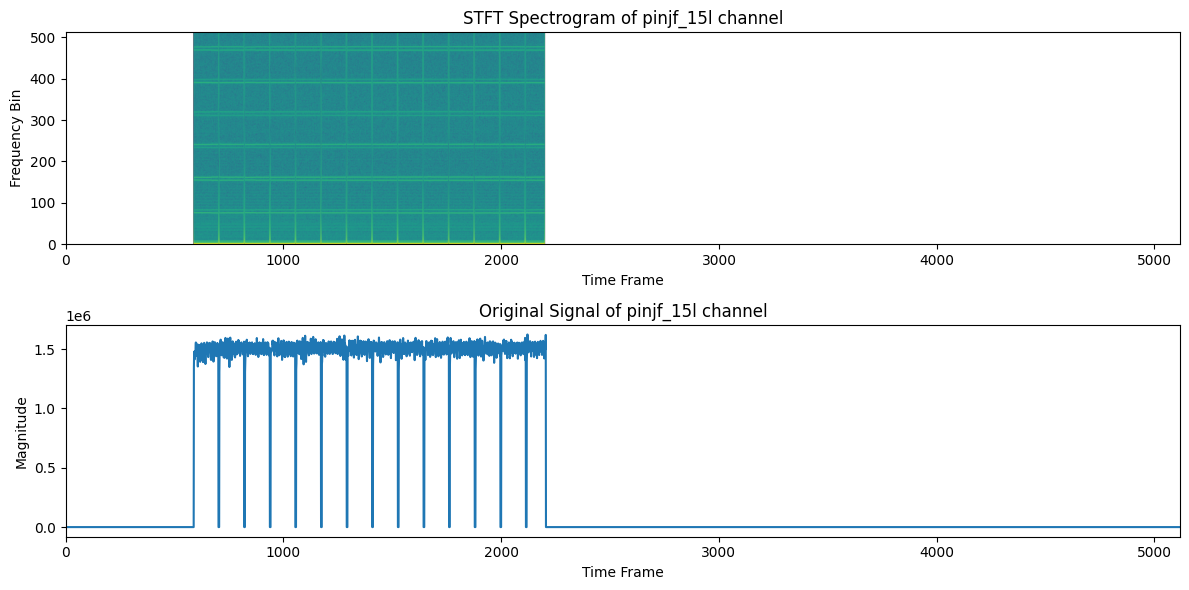

In [166]:
# Plot the spectrogram
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.imshow(log_abs_stft.numpy(), aspect='auto', origin='lower', cmap='viridis')
plt.xlabel('Time Frame')
plt.ylabel('Frequency Bin')
plt.title('STFT Spectrogram of pinjf_15l channel')
plt.subplot(2, 1, 2)
plt.plot(decimated_signal)
plt.xlim(0, len(decimated_signal))
plt.xlabel('Time Frame')
plt.ylabel('Magnitude')
plt.title('Original Signal of pinjf_15l channel')
plt.tight_layout()
plt.show()
